In [4]:
#Khai báo các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
  # Hiển thị 5 hàng đầu của dữ liệu
df = pd.read_csv('/kaggle/input/datasets/ngyyenhon/ssaaxc/credit_card_transactions.csv')
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [7]:
# Kiểm tra số lượng và kiểu dữ liệu của dữ liệu
print(df.shape)       # (số_dòng, số_cột)
print(df.shape[0])    # số dòng
print(df.shape[1])    # số cột

print(df.info())      # thông tin toàn bộ DataFrame

(1296675, 24)
1296675
24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float6

In [8]:
# Sử dụng hàm describe() để thống kê dữ liệu
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.100702e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,4.682575e+04
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,2.583400e+04
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1.001000e+03
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,2.511400e+04
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,4.586000e+04
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,6.831900e+04
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,9.940300e+04


In [ ]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

####1. trans_date_trans_time: thời gian thực hiện giao dịch
####2. cc_num: mã định danh thẻ tín dụng của khách hàng
####3. merchant: tên người bàn hàng
####4. category: loại hình kinh doanh
####5. amt: số tiền giao dịch
####6. first: tên riêng của khách hàng
####7. last: họ của khách hàng
####8. gender: giới tính của khách hàng
####9. street: địa chỉ nhà của khách hàng
####10. state: bang nơi khách hàng lưu trú
####11. zip: mã bưu điện nơi khách hàng lưu trú
####12. lat: vĩ độ của địa chỉ nhà khách hàng
####13. long: kinh độ của địa chỉ nhà khách hàng
####14. city_pop: dân số thành phố nơi khách hàng lưu trú
####15. job: nghề nghiệp của khách
####16. dob: ngày sinh của khách  
####17. trans_num: số định danh của giao dịch
####18. unix_time: thời gian giao dịch được ghi nhận dưới dạng dấu thời gian Unix
####19. merch_lat: vĩ độ của giao dịch
####20. merch_long: kinh độ của giao dịch
####21. is_fraud: giao dịch có phải gian lận hay không
####22. merch_zipcode: mã bưu điện nơi diễn ra giao dịch

In [ ]:
df.isna().sum()


,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


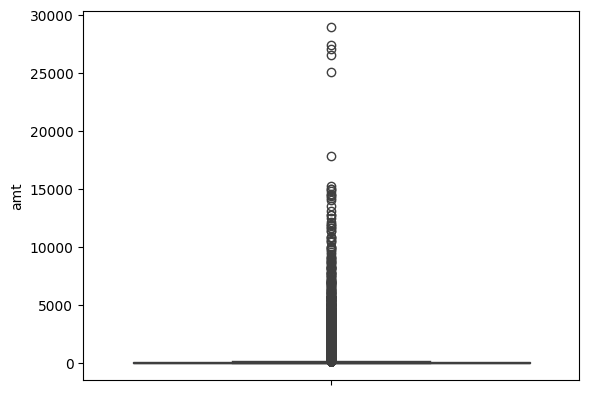

In [ ]:
sns.boxplot(df["amt"])
plt.show()

In [ ]:
q1 = df["amt"].quantile(0.25)
q3 = df["amt"].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print("q1 : ", q1)
print("q3 : ", q3)
print("IQR : ", IQR)
print("lower_bound : ", lower_bound)
print("upper_bound : ", upper_bound)

q1 :  9.65
q3 :  83.14
IQR :  73.49
lower_bound :  -100.58499999999998
upper_bound :  193.375


In [13]:
df.drop(columns=['merch_zipcode'], inplace=True)

In [14]:
print("Tổng missing còn lại:", df.isnull().sum().sum())

Tổng missing còn lại: 0


In [1]:
!pip install torch scikit-learn pandas numpy joblib matplotlib

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import os

numeric_cols = ['amt', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']
X = df[numeric_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)
model.fit(X_scaled)

IsolationForest(contamination=0.02, n_jobs=-1, random_state=42)

In [12]:
from sklearn.metrics import classification_report

y_true = df['is_fraud'].astype(int)

pred_raw = model.predict(X_scaled)

y_pred = np.where(pred_raw == -1, 1, 0)

anomaly_score = -model.decision_function(X_scaled)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0     0.9956    0.9813    0.9884   1289169
           1     0.0723    0.2498    0.1121      7506

    accuracy                         0.9771   1296675
   macro avg     0.5339    0.6156    0.5503   1296675
weighted avg     0.9902    0.9771    0.9833   1296675



In [20]:
numeric_cols = ['amt', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']

X_raw = df[numeric_cols].copy()
y = df['is_fraud'].astype(int)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.metrics import classification_report

X_train_normal = X_train[y_train == 0]

mu = X_train_normal.mean()
sigma = X_train_normal.std().replace(0, 1e-6)

z_test = ((X_test - mu) / sigma).abs()
score_z = z_test.max(axis=1)

threshold = 3.0
y_pred_z = (score_z > threshold).astype(int)

print("\nClassification report:")
print(classification_report(y_test, y_pred_z, digits=4, zero_division=0))


Classification report:
              precision    recall  f1-score   support

           0     0.9969    0.9637    0.9800    257834
           1     0.0729    0.4903    0.1270      1501

    accuracy                         0.9610    259335
   macro avg     0.5349    0.7270    0.5535    259335
weighted avg     0.9916    0.9610    0.9751    259335

